# ✨ YAPAY ZEKA TOPLULUĞU SENİOR KAMPI B26

# 🎯 HAFTA 4


## *1.Renk Uzayları Nedir?*


**Renk uzayı**, bir görüntüdeki renklerin sayısal olarak nasıl temsil edildiğini tanımlar. Görüntü işleme algoritmalarının başarısı, kullanılan renk uzayına doğrudan bağlıdır.
En yaygın kullanılan renk uzaylarından ikisi **BGR** ve **HSV**’dir.

#  BGR ve HSV


🖥️ **BGR (Blue – Green – Red) Renk Uzayı**



BGR, görüntülerin donanıma ve ekrana en yakın temsil biçimidir. OpenCV kütüphanesinde varsayılan renk uzayıdır.
Her piksel 3 kanaldan oluşur:
* **Mavi (B)**,
* **Yeşil (G)**,
* **Kırmızı (R)**

Piksel değeri genellikle 0–255 aralığındadır.
Renk ve parlaklık bilgisi birbirinden ayrılmamıştır.

Renk kombinasyonları:
* Green(255) + Red(255) = Yellow
* Green(255) + Blue(255) = Cyan
* Red(255) + Blue(255) = Magenta
* Red(255) + Green(255) + Blue(255) = White

📌 Önemli Nokta:
Işık değişimleri (gölge, parlaklık, kamera açısı) BGR değerlerini doğrudan etkiler.


🎨 **HSV (Hue – Saturation – Value) Renk Uzayı**

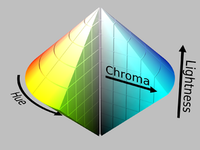

HSV renk uzayı, insanın renk algısına daha yakın bir modeldir.

* **Hue (H)**: Renk türü (kırmızı, mavi, yeşil vb.)
* **Saturation (S)**: Rengin doygunluğu (canlılık)
* **Value (V)**: Parlaklık (ışık seviyesi)

Bu yapıda renk bilgisi (H) ile ışık bilgisi (V) birbirinden ayrıdır.


🎯 **HSV’nin Nesne Takibindeki Önemi**

Nesne takibi uygulamalarında amaç, görüntüden belirli bir rengi veya nesneyi ayıklamaktır.

BGR’de renk ve parlaklık iç içe olduğu için:
* Gölge
* Aydınlatma farkı
*	Kamera pozlaması
gibi etkenler hatalı sonuçlara yol açar.

HSV’de ise:

*	Sadece Hue (H) kanalına odaklanılarak
*	Işıktan bağımsız, daha kararlı maskeleme yapılabilir.



## *2. Maskeleme (Masking)*


**Maskeleme**, bir görüntüde belirli bir özelliğe (çoğunlukla renk) sahip piksellerin seçilerek, diğer tüm piksellerin yok sayılması işlemidir. Amaç, görüntüden ilgili nesneyi arka plandan ayırmaktır.



🧠 Maskeleme Mantığı
Bilgisayar her piksel için şu soruyu sorar:
“Bu piksel, benim belirlediğim renk aralığında mı?”
* Evet → 1 (Beyaz)
* Hayır → 0 (Siyah)

Bu işlem sonucunda ikili (binary) bir maske görüntüsü elde edilir.



🎨 **Neden HSV ile Maskeleme Yapılır?**

BGR renk uzayında:
Renk ve parlaklık iç içedir
Işık değişimleri maske sonucunu bozar
HSV renk uzayında:
Hue (H): Renk bilgisi
Saturation (S): Renk doygunluğu
Value (V): Parlaklık

📌 Avantaj:
Maskeleme sırasında sadece Hue kanalına odaklanılarak, ışık değişimlerinden büyük ölçüde bağımsız sonuç elde edilir.



🔍 **Renk Aralığı Belirleme (Color Thresholding)**

Maskeleme işlemi, belirli bir alt–üst renk aralığı tanımlanarak yapılır.
Alt sınır (Lower Bound)
Üst sınır (Upper Bound)
Her pikselin HSV değeri bu aralıkta mı diye kontrol edilir.


🧩 **Maskeleme İşleminin Adımları**
1.	Görüntüyü BGR → HSV renk uzayına dönüştür
2.	Hedef renk için HSV alt ve üst sınırlarını belirle
3.	Bu sınırlara göre maske oluştur
4.	Maskeyi kullanarak orijinal görüntüden sadece istenen nesneyi ayıkla


🎯 **Maskelemenin Kullanım Alanları**
* Nesne takibi
* Renk tabanlı segmentasyon
* Otonom araç sistemleri
* Endüstriyel kalite kontrol
* Medikal görüntü analizi


✅ Sonuç
Maskeleme, görüntü işlemede nesne ayıklamanın temel taşıdır. Doğru renk uzayı (HSV) ve doğru aralıklar seçildiğinde, karmaşık sahnelerde bile oldukça başarılı sonuçlar elde edilir.


In [ ]:
#📌 Örnek:
 #“Kırmızı bir topu takip et” problemi:
import cv2
import numpy as np

# Kamerayı aç (0 = varsayılan kamera)
cap = cv2.VideoCapture(0)

while True:
    # Kameradan bir kare al
    ret, frame = cap.read()
    if not ret:
        break

    # 1️⃣ BGR → HSV dönüşümü
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2️⃣ Kırmızı renk için HSV aralıkları
    # Kırmızı HSV'de iki bölgede yer alır
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])

    # 3️⃣ Maske oluşturma
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    # İki maskeyi birleştir
    mask = mask1 + mask2

    # 4️⃣ Maskeyi orijinal görüntüye uygula
    result = cv2.bitwise_and(frame, frame, mask=mask)

    # 5️⃣ Görüntüleri göster
    cv2.imshow("Orijinal Goruntu", frame)
    cv2.imshow("Kirmizi Maske", mask)
    cv2.imshow("Kirmizi Nesne", result)

    # 'q' tuşuna basılırsa çık
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Kaynakları serbest bırak
cap.release()
cv2.destroyAllWindows()


## *3.  Bulanıklaştırma (Blurring & Smoothing)*


**Bulanıklaştırma**, görüntüdeki istenmeyen gürültüyü azaltmak ve daha pürüzsüz bir görüntü elde etmek için kullanılan temel bir ön işleme adımıdır. Özellikle maskeleme ve kenar algılama öncesinde sıkça uygulanır.

### Orijinal Görüntü
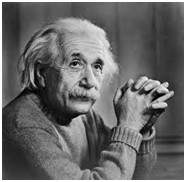

### Bulanıklaştırılmış Görüntü
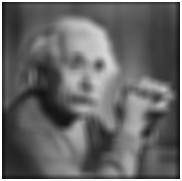


🧠 **Gürültü (Noise) Nedir?**

Gürültü, görüntüde olması gereken bilginin dışında kalan rastgele bozulmalardır.
Beyaz noktalar
Siyah noktalar
Rastgele piksel sıçramaları

📌 En yaygın türlerden biri **tuz-biber (salt & pepper)** gürültüsüdür.

### 🧮 3.1. Gaussian Blur
**Gaussian Blur**, bir pikselin değerini komşu piksellerin ağırlıklı ortalamasını alarak hesaplar. Ağırlıklar, Gaussian (çan eğrisi) dağılımına göre belirlenir.
Yumuşak ve doğal bulanıklaştırma sağlar
Genel gürültüyü azaltır.
Kenarlar bir miktar yumuşar.

📌 Kullanım alanı:
* Görüntü yumuşatma
* Genel gürültü azaltma
* Kenar algılama öncesi ön işlem


### ⚫ 3.2. Median Blur
**Median Blur**, piksel değerini komşu piksellerin medyan değeri ile değiştirir.
Ortalama almaz, sıralama yapar.
Kenarları Gaussian’a göre daha iyi korur.
Tuz-biber gürültüsüne karşı çok etkilidir.Bu teknik, aşırı uç değerleri (0 ve 255) bastırarak nesnenin şeklini korur.

📌 Kullanım alanı:

* Siyah-beyaz noktaların temizlenmesi
* Gürültülü görüntülerde nesne korunumu

### 🎯 3.3. Tuz-Biber Gürültüsünü Temizleme

**Tuz-biber gürültüsü**, bir görüntüde rastgele ortaya çıkan saf siyah ve saf beyaz piksel noktaları şeklindeki gürültü türüdür.

* Beyaz noktalar (255) → Tuz
* Siyah noktalar (0) → Biber


✅ Sonuç

Gaussian Blur: Genel yumuşatma ve düşük seviyeli gürültü

Median Blur: Tuz-biber gürültüsü temizleme

> **Not:** Bulanıklaştırma seviyesi fazla olursa, önemli detaylar kaybolabilir. Bu nedenle çekirdek (kernel) boyutu dikkatli seçilmelidir.

In [ ]:
import cv2

# 1️⃣ Resmi oku (gri tonlamalı)
img = cv2.imread("noisy_image.jpg", 0)

# Hata kontrolü
if img is None:
    print("❌ Resim bulunamadı!")
    exit()

# 2️⃣ Median Blur uygula
# 5 -> çekirdek boyutu (tek sayı olmak zorunda)
clean = cv2.medianBlur(img, 5)

# 3️⃣ Sonuçları göster
cv2.imshow("Tuz-Biber Gurultulu", img)
cv2.imshow("Median Blur Sonucu", clean)

cv2.waitKey(0)
cv2.destroyAllWindows()


## *4. Morfolojik İşlemler 🧩*


**Morfolojik işlemler**, genellikle ikili (binary) görüntüler üzerinde çalışan ve nesnelerin şekillerini düzenlemek için kullanılan temel görüntü işleme teknikleridir. Özellikle maskeleme sonrası oluşan gürültüyü temizlemek için kullanılır.


🧠 **Morfolojik İşlemlerin Temel Mantığı**

Bu işlemler, görüntü üzerinde küçük bir yapı elemanı (kernel / structuring element) gezdirilerek uygulanır.
Her piksel için şu soru sorulur:
“Bu pikselin komşuluğu, belirlenen yapıya uyuyor mu?”
Sonuç, nesnenin şeklinin küçülmesi veya büyümesi şeklinde ortaya çıkar.

Örnek bir kernel:

1 1 1

1 1 1

1 1 1

Pikselin komşularını temsil eder

“Bu pikselin çevresi uygun mu?” sorusunu sorar




### 🧱 4.1. Erosion (Aşındırma)

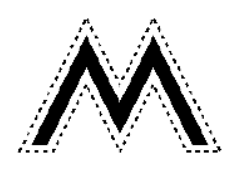

**Erosion**, beyaz (1) bölgeleri küçülten bir işlemdir.

*	Küçük beyaz gürültüleri yok eder
* Nesnenin kenarlarını aşındırır
*	İnce detayları silebilir.

📌 Etkisi:

*	Beyaz alanlar daralır
*	Siyah alanlar genişler.

🎯 Kullanım amacı:

* Gürültü temizleme
* Küçük ve istenmeyen beyaz noktaları kaldırma




In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
erosion = cv2.erode(mask, kernel)


### ➕ 4.2. Dilation (Yayma)

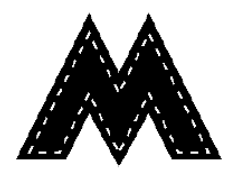

**Dilation**, beyaz (1) bölgeleri genişleten bir işlemdir.

*	Nesne içindeki boşlukları doldurur
*	Kopuk parçaları birleştirir
*	Nesneyi daha belirgin hale getirir.

📌 Etkisi:

*	Beyaz alanlar büyür
*	Siyah alanlar daralır.

🎯 Kullanım amacı:

*	Nesne güçlendirme
*	Parçalanmış yapıları birleştirme




In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
dilation = cv2.dilate(mask, kernel)


### 🔄 4.3. Erosion ve Dilation Birlikte Kullanımı
Gerçek uygulamalarda bu iki işlem tek başına değil, birlikte kullanılır.

📌 En yaygın sıra:

1.	Erosion → Gürültüyü temizle
2.	Dilation → Asıl nesneyi geri büyüt

Bu kombinasyon sayesinde:

✔ Gürültü silinir
✔ Nesne formu korunur
✔ Net ve takip edilebilir yapılar elde edilir


🧪 Maskeleme sonrası görüntülerde,küçük beyaz noktalar, delikli nesneler, kopuk alanlar
sıklıkla görülür. Morfolojik işlemler bu problemleri çözmek için kritik bir adımdır.

✅ Sonuç

•	Erosion: Gürültü temizler, nesneyi küçültür.

•	Dilation: Nesneyi güçlendirir, boşlukları doldurur.

•	Birlikte kullanıldığında: Gürültüsüz, net ve sağlam nesneler elde edilir.

> **Not:** Yapı elemanının (kernel) boyutu büyüdükçe etki artar, ancak fazla büyütülürse nesne şekli bozulabilir.

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
clean = cv2.erode(mask, kernel)
clean = cv2.dilate(clean, kernel)


# 📚 Ekstra Kaynak Önerisi: Videolu Anlatım

* [YouTube Videosuna Git](https://youtu.be/kdlAFEzEuJw?si=tKa46rmhaYgwtY3g)
* [YouTube Videosuna Git](https://youtu.be/1Br4Vo3Hui8?si=jAkYctNV6g79mpEm)
* [YouTube Videosuna Git](https://youtu.be/D4j0bnmUjhs?si=R0mRiy6ZTL2TjKnk)
* [YouTube Videosuna Git](https://youtu.be/S_cD0i_DpdU?si=mNsQ7-14ub3tFQp5)



# 🔬 İleri Okuma ve Araştırma Kaynakları

📘 Görüntü İşleme İçin Temel ve Akademik Kaynaklar:



### 🧠 1. Renk Modelleri ve Teorik Temel

* **📄 [Renk Modelleri — RGB, CMYK, HSV ve YIQ]( https://www.geeksforgeeks.org/computer-graphics/difference-between-rgb-cmyk-hsv-and-yiq-color-models/?utm)**

    * *Neden Okumalısın?* Görüntü işlemeye başlamadan önce renk uzaylarını anlamak kritik. Bu makale RGB, CMYK, HSV ve YIQ gibi temel renk modellerinin ne olduğunu, nasıl çalıştığını ve hangi amaçlarla kullanıldığını örneklerle açıklar.Görüntü işleme algoritmalarında renk uzayı dönüşümleri çok sık kullanılır; bu kaynak buna sağlam bir giriş sağlar.

### 📘 2. Akademik ve Uygulamalı Çalışma

* **📄 [Görüntü İşleme Uygulamaları (IJARCCE)](https://ijarcce.com/wp-content/uploads/2021/04/IJARCCE.2021.10317.pdf)**


    * *Neden Okumalısın?* Bu akademik çalışma, görüntü işleme algoritmalarını ve bu algoritmaların uygulamalarını bilimsel bir çerçevede anlatır.Algoritmaların matematiksel temelleri, performans değerlendirmeleri ve farklı tekniklerin karşılaştırılması gibi akademik detaylar bu tür makalelerde bulunur.

### 🧠 3. Derin Öğrenme ve Modern Yöntemler

* **📄 [Arxiv — Görüntü İşleme ve Derin Öğrenme](https://arxiv.org/pdf/2510.00584)**

    * *Neden Okumalısın?* Görüntü işleme alanındaki modern derin öğrenme tabanlı yaklaşımları bilimsel düzeyde öğrenmek istiyorsan bu çalışma önemli bir kaynaktır.Derin öğrenme, güncel nesne tespiti, segmentasyon ve görsel tanıma tekniklerinin matematiksel altyapısı bu makalede bulunabilir.

### 🛠️ 4. Renk Uzayları ve Uygulamada Kullanımı

* **📄 [OpenCV’de Renk Uzayları (LearnOpenCV)](https://learnopencv.com/color-spaces-in-opencv-cpp-python/?utm)**

    * *Neden Okumalısın?* Bu kaynak, OpenCV kullanarak değişik renk uzaylarının nasıl uygulandığını açıklar (RGB’den HSV’ye dönüşüm, BGR vs RGB vb.). Pratik kod örnekleriyle birlikte renk uzaylarını deneyimlemek, gerçek projelerde hata yapma olasılığını azaltır.


### 🌀 5. Görüntü Ön‑İşleme: Blurring (Bulanıklaştırma)

* **📄 [Tutorialspoint — Concept of Blurring](https://www.tutorialspoint.com/dip/concept_of_blurring.htm)**

    * *Neden Okumalısın?* Görüntüyü bulanıklaştırma kavramı, neden yapıldığı ve hangi filtrelerin (ör. box filter, weighted average) kullanıldığını öğretir — bu, birçok ön‑işleme adımında kritik bir tekniktir.

### 🧩 6. Görüntü Filtreleme: Masks (Maskeler)

* **📄 [Tutorialspoint — Concept of Masks](https://www.tutorialspoint.com/dip/concept_of_masks.htm)**


    * *Neden Okumalısın?* Maskeler (filtreler) görüntüler üzerinde işlem yapmanın temel aracıdır. Bir mask 2B bir matristir (örneğin 3×3) ve konvolüsyon yardımıyla görüntüye uygulanır. Filtreler,gürültü azaltma ve bulanıklaştırma,kenar tespiti ve keskinleştirmegibi işlemleri yapar.Maskeler, her piksel çevresindeki komşularla çarpılarak yeni değerler hesaplar; bu sayede görüntü üzerinde belirli efektler (örneğin kenar vurgulama) elde edilir.
